In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

file1 = Path("/Users/thunthita/Lidarforiypnb/LIDar/ExampleCode/Pipeline_Test/telemetry_sched_P1_20260408_085800.csv")
file2 = Path("/Users/thunthita/Lidarforiypnb/LIDar/ExampleCode/Pipeline_Test/telemetry_20260408.csv")
out   = Path("/Users/thunthita/Lidarforiypnb/LIDar/ExampleCode/Pipeline_Test/telemetry_fixed_20260408.csv")

# file1 has header
df1 = pd.read_csv(file1)

# file2 has NO header
df2 = pd.read_csv(file2, header=None)

# force same columns as file1
df2.columns = df1.columns

# concat: file2 comes after file1
df = pd.concat([df1, df2], ignore_index=True)

In [2]:
file3 = Path("/Users/thunthita/Lidarforiypnb/LIDar/ExampleCode/Pipeline_Test/telemetry_sched_P1_20260407_125800.csv")
# file1 has header
df3 = pd.read_csv(file3)

# build datetime
df3["datetime"] = pd.to_datetime(
    df3["Date"].astype(str) + " " + df3["Time"].astype(str),
    format="mixed",
    dayfirst=True,
    errors="coerce"
)

# numeric DTEMF
df3["DTEMF"] = pd.to_numeric(df3["DTEMF"], errors="coerce")

# drop bad rows
df3 = df3.dropna(subset=["datetime", "DTEMF"]).copy()

print("start:", df3["datetime"].min())
print("end:  ", df3["datetime"].max())


start: 2026-04-07 12:57:41
end:   2026-04-07 16:00:00


In [3]:
df["LTEMF"]

0       25.48
1       25.48
2       25.48
3       25.48
4       25.50
        ...  
8335    26.87
8336    26.87
8337    26.93
8338    26.93
8339    27.00
Name: LTEMF, Length: 8340, dtype: float64

saved to: /Users/thunthita/Lidarforiypnb/LIDar/ExampleCode/Pipeline_Test/telemetry_fixed_20260408.csv
start: 2026-04-08 08:57:41
end:   2026-04-08 16:00:00


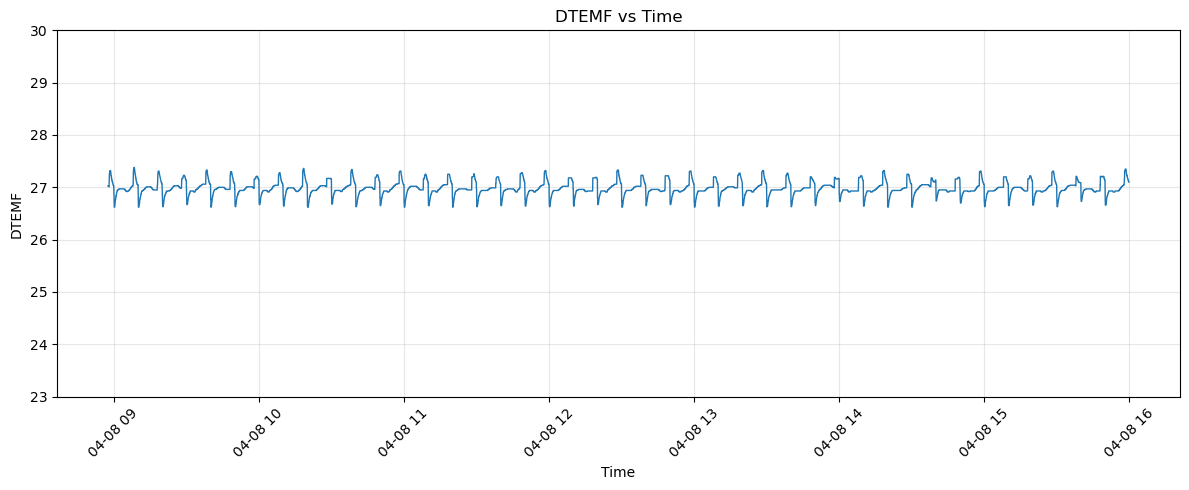

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

file1 = Path("/Users/thunthita/Lidarforiypnb/LIDar/ExampleCode/Pipeline_Test/telemetry_sched_P1_20260408_085800.csv")
file2 = Path("/Users/thunthita/Lidarforiypnb/LIDar/ExampleCode/Pipeline_Test/telemetry_20260408.csv")
out   = Path("/Users/thunthita/Lidarforiypnb/LIDar/ExampleCode/Pipeline_Test/telemetry_fixed_20260408.csv")

# file1 has header
df1 = pd.read_csv(file1)

# file2 has NO header
df2 = pd.read_csv(file2, header=None)

# force same columns as file1
df2.columns = df1.columns

# concat: file2 comes after file1
df = pd.concat([df1, df2], ignore_index=True)

# save fixed merged file
df.to_csv(out, index=False)
print("saved to:", out)

# build datetime
df["datetime"] = pd.to_datetime(
    df["Date"].astype(str) + " " + df["Time"].astype(str),
    format="mixed",
    dayfirst=True,
    errors="coerce"
)

# numeric DTEMF
df["DTEMF"] = pd.to_numeric(df["DTEMF"], errors="coerce")

# drop bad rows
df = df.dropna(subset=["datetime", "DTEMF"]).copy()

print("start:", df["datetime"].min())
print("end:  ", df["datetime"].max())

# plot
plt.figure(figsize=(12, 5))
plt.plot(df["datetime"], df["DTEMF"], linewidth=1)

plt.xlabel("Time")
plt.ylabel("DTEMF")
plt.title("DTEMF vs Time")
plt.ylim(23, 30)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

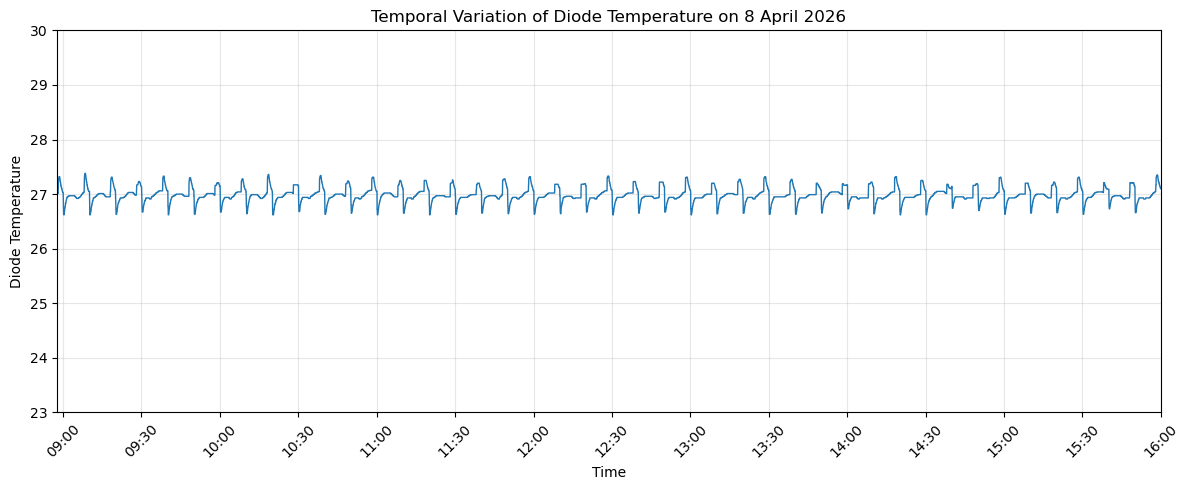

In [9]:
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df["datetime"], df["DTEMF"], linewidth=1)

# IMPORTANT: lock x-axis to real data range
xmin = df["datetime"].min()
xmax = df["datetime"].max()
ax.set_xlim(xmin, xmax)

# 30-minute ticks
ax.xaxis.set_major_locator(mdates.MinuteLocator(byminute=[0, 30]))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))

ax.set_xlabel("Time")
ax.set_ylabel("Diode Temperature")
ax.set_title("Temporal Variation of Diode Temperature on 8 April 2026")
ax.set_ylim(23, 30)
ax.grid(True, alpha=0.3)

plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("diode_temperature_20260408.png")
plt.show()

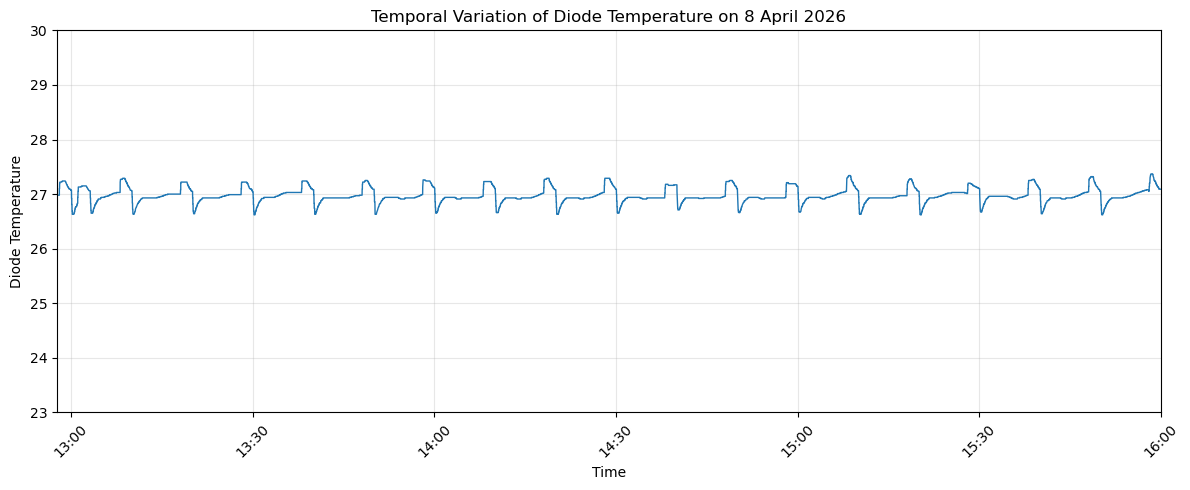

In [11]:
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df3["datetime"], df3["DTEMF"], linewidth=1)

# IMPORTANT: lock x-axis to real data range
xmin = df3["datetime"].min()
xmax = df3["datetime"].max()
ax.set_xlim(xmin, xmax)

# 30-minute ticks
ax.xaxis.set_major_locator(mdates.MinuteLocator(byminute=[0, 30]))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))

ax.set_xlabel("Time")
ax.set_ylabel("Diode Temperature (°C)")
ax.set_title("Temporal Variation of Diode Temperature on 8 April 2026")
ax.set_ylim(23, 30)
ax.grid(True, alpha=0.3)

plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("diode_temperature_20260408.png")
plt.show()

In [28]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

def plot_time_series(
    df,
    x_col="datetime",
    y_col="DTEMF",
    xlabel="Time",
    ylabel="Diode Temperature",
    title="Temporal Variation",
    ylim=None,
    xlim=None,
    tick_interval_min=30,
    figsize=(12, 5),
    save_path=None
):
    """
    Generic time-series plot function.

    Parameters
    ----------
    df : pandas.DataFrame
        Input dataframe
    x_col : str
        Column for x-axis
    y_col : str
        Column for y-axis
    xlabel, ylabel : str
        Axis labels
    title : str
        Plot title
    ylim : tuple or None
        y-axis limits
    xlim : tuple or None
        x-axis limits
    tick_interval_min : int
        x-axis tick interval in minutes
    figsize : tuple
        Figure size
    save_path : str or None
        Save figure path
    """

    fig, ax = plt.subplots(figsize=figsize)

    # plot
    ax.plot(df[x_col], df[y_col], linewidth=1)

    # x-axis range
    if xlim is None:
        xlim = (df[x_col].min(), df[x_col].max())
    ax.set_xlim(*xlim)

    # x-axis ticks
    ax.xaxis.set_major_locator(
        mdates.MinuteLocator(interval=tick_interval_min)
    )
    ax.xaxis.set_major_formatter(
        mdates.DateFormatter("%H:%M")
    )

    # labels
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)

    # y-axis
    if ylim:
        ax.set_ylim(*ylim)

    ax.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Saved to: {save_path}")

    plt.show()



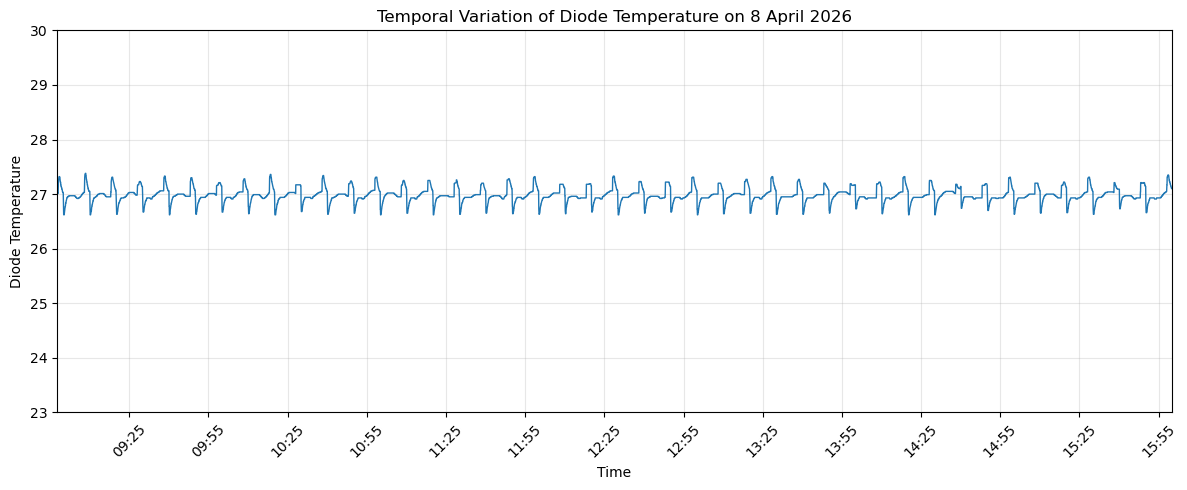

In [54]:
plot_time_series(
    df,
    y_col="DTEMF",
    ylabel="Diode Temperature",
    title="Temporal Variation of Diode Temperature on 8 April 2026",
    ylim=(23, 30)
)

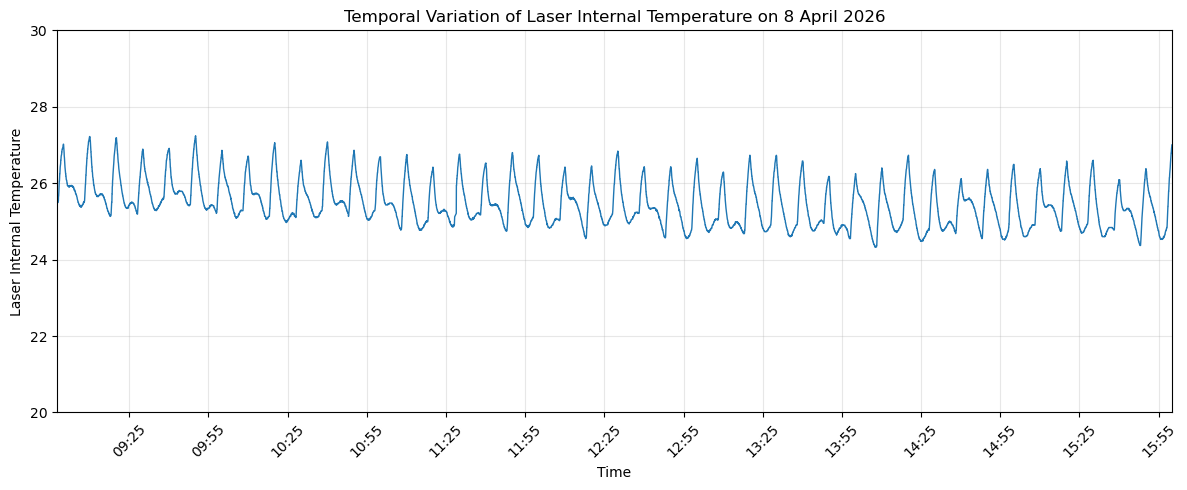

In [40]:
plot_time_series(
    df,
    y_col="LTEMF",
    ylabel="Laser Internal Temperature",
    title="Temporal Variation of Laser Internal Temperature on 8 April 2026",
    ylim=(20, 30)
)

In [13]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

def plot_temperature_vs_time(
    df,
    time_col="datetime",
    temp_col="DTEMF",
    tick_interval=10,
    ylim=(23, 30),
    tick_range=None,
    title="Temporal Variation of Diode Temperature",
    ylabel="Diode Temperature",
    figsize=(12, 5),
    save_path=None
):
    """
    Plot full temperature data but allow custom x-axis tick range.

    tick_range = (start_time, end_time)
    """

    fig, ax = plt.subplots(figsize=figsize)

    # plot full data
    ax.plot(df[time_col], df[temp_col], linewidth=1)

    # full x-axis data range always shown
    ax.set_xlim(df[time_col].min(), df[time_col].max())

    # custom ticks
    if tick_range is not None:
        tick_start, tick_end = tick_range
        ticks = pd.date_range(
            start=tick_start,
            end=tick_end,
            freq=f"{tick_interval}min"
        )
        ax.set_xticks(ticks)
    else:
        ax.xaxis.set_major_locator(
            mdates.MinuteLocator(interval=tick_interval)
        )

    ax.xaxis.set_major_formatter(
        mdates.DateFormatter("%H:%M")
    )

    ax.set_xlabel("Time")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.set_ylim(*ylim)
    ax.grid(True, alpha=0.3)

    plt.xticks(rotation=45)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Saved to: {save_path}")

    plt.show()

Saved to: D_diode_temperature_20260407.png


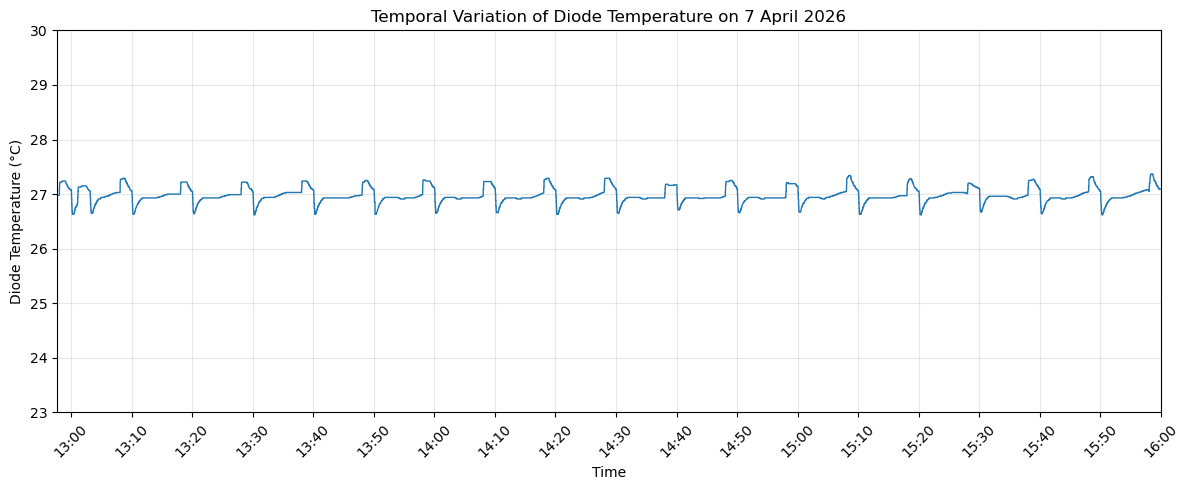

In [15]:
plot_temperature_vs_time(
    df3,
    temp_col="DTEMF",
    tick_interval=10,
    tick_range=(
        "2026-04-07 13:00:00",
        "2026-04-07 16:00:00"
    ),
    ylim=(23, 30),
    title="Temporal Variation of Diode Temperature on 7 April 2026",
    ylabel="Diode Temperature (°C)",
    save_path="D_diode_temperature_20260407.png"
)

Saved to: L_diode_temperature_20260407.png


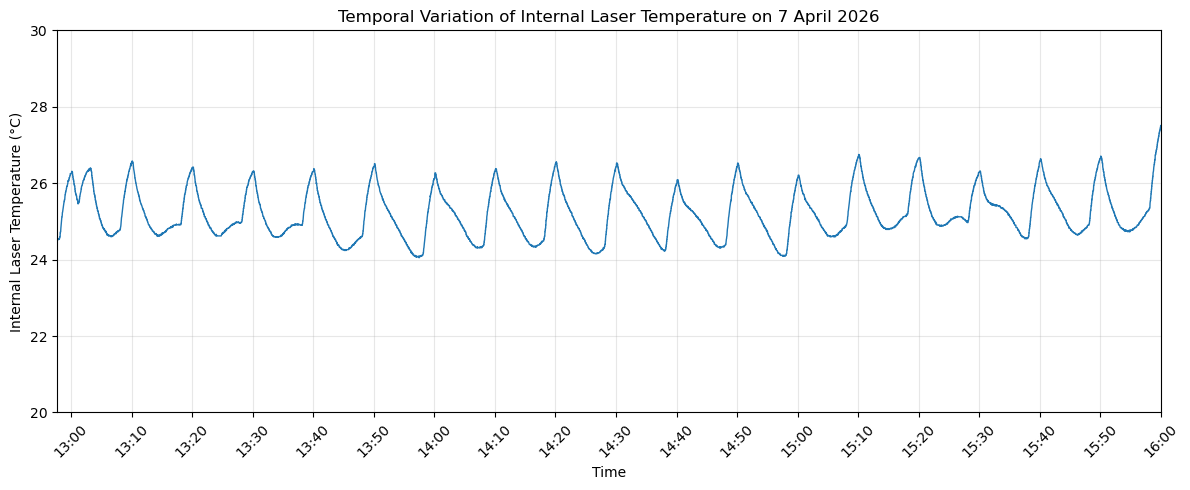

In [17]:
plot_temperature_vs_time(
    df3,
    temp_col="LTEMF",
    tick_interval=10,
    tick_range=(
        "2026-04-07 13:00:00",
        "2026-04-07 16:00:00"
    ),
    ylim=(20, 30),
    title="Temporal Variation of Internal Laser Temperature on 7 April 2026",
    ylabel="Internal Laser Temperature (°C)",
    save_path="L_diode_temperature_20260407.png"
)

Saved to: D_diode_temperature_20260408.png


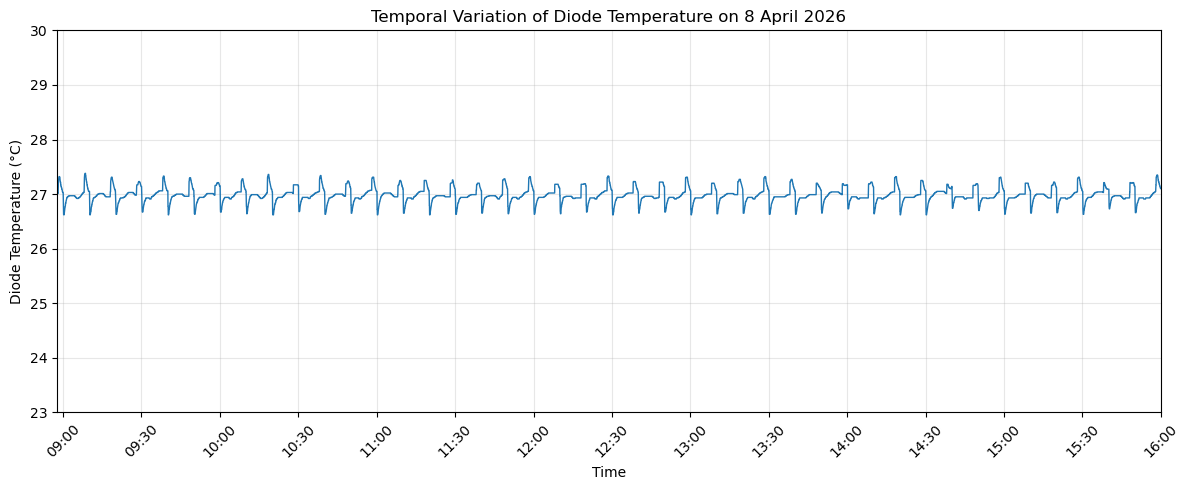

In [19]:
plot_temperature_vs_time(
    df,
    temp_col="DTEMF",
    tick_interval=30,
    tick_range=(
        "2026-04-08 09:00:00",
        "2026-04-08 16:00:00"
    ),
    ylim=(23, 30),
    title="Temporal Variation of Diode Temperature on 8 April 2026",
    ylabel="Diode Temperature (°C)",
    save_path="D_diode_temperature_20260408.png"
)

Saved to: L_diode_temperature_20260408.png


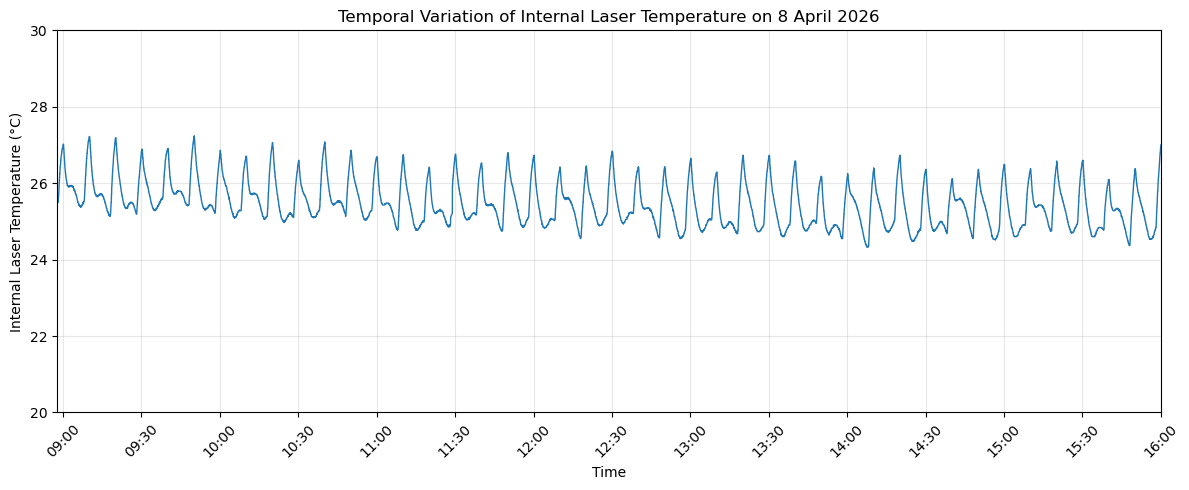

In [21]:
plot_temperature_vs_time(
    df,
    temp_col="LTEMF",
    tick_interval=30,
    tick_range=(
        "2026-04-08 09:00:00",
        "2026-04-08 16:00:00"
    ),
    ylim=(20, 30),
    title="Temporal Variation of Internal Laser Temperature on 8 April 2026",
    ylabel="Internal Laser Temperature (°C)",
    save_path="L_diode_temperature_20260408.png"
)